In [1]:
import tensorflow as tf

print(tf.__version__)


2.15.0


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [4]:
data = load_breast_cancer()

X = data.data
y = data.target

print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
model = Sequential()

model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [8]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/50


23/23 [==============================] - 7s 37ms/step - loss: 0.6611 - accuracy: 0.6484 - val_loss: 0.6117 - val_accuracy: 0.7582
Epoch 2/50
23/23 [==============================] - 0s 15ms/step - loss: 0.5714 - accuracy: 0.7720 - val_loss: 0.5188 - val_accuracy: 0.8242
Epoch 3/50
23/23 [==============================] - 0s 9ms/step - loss: 0.4889 - accuracy: 0.8434 - val_loss: 0.4318 - val_accuracy: 0.8571
Epoch 4/50
23/23 [==============================] - 0s 11ms/step - loss: 0.4108 - accuracy: 0.8874 - val_loss: 0.3617 - val_accuracy: 0.8791
Epoch 5/50
23/23 [==============================] - 0s 13ms/step - loss: 0.3441 - accuracy: 0.9148 - val_loss: 0.3060 - val_accuracy: 0.9011
Epoch 6/50
23/23 [==============================] - 0s 9ms/step - loss: 0.2844 - accuracy: 0.9286 - val_loss: 0.2569 - val_accuracy: 0.9231
Epoch 7/50
23/23 [==============================] - 0s 7ms/step - loss: 0.2312 - accuracy: 0.9368 - val_loss: 0.2187 - val_accuracy: 0.9451
Epoch 8/50
23/

In [10]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)

4/4 [==============================] - 0s 5ms/step - loss: 0.0634 - accuracy: 0.9825
Loss: 0.06344209611415863
Accuracy: 0.9824561476707458


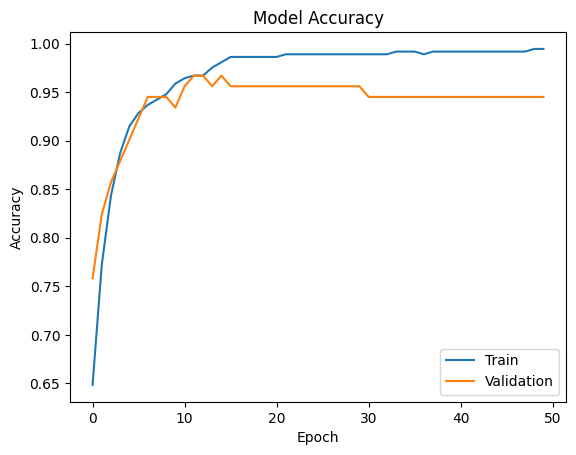

In [11]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

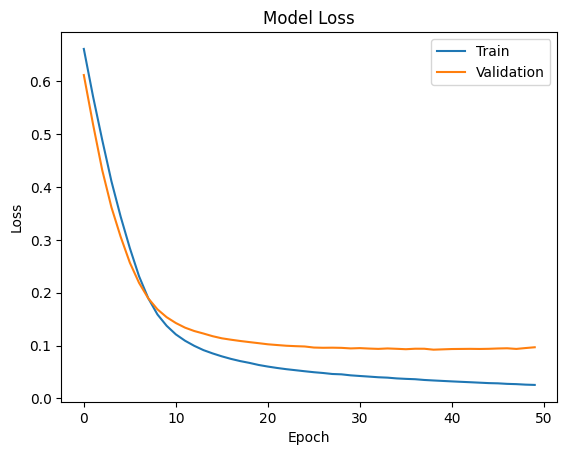

In [12]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

In [13]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                496       
                                                                 
 dense_1 (Dense)             (None, 8)                 136       
                                                                 
 dense_2 (Dense)             (None, 1)                 9         
                                                                 
Total params: 641 (2.50 KB)
Trainable params: 641 (2.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [14]:
predictions = model.predict(X_test)

print(predictions[:5])

4/4 [==============================] - 0s 4ms/step
[[9.6874201e-01]
 [5.2733540e-06]
 [4.0350793e-04]
 [9.9955702e-01]
 [9.9998516e-01]]


In [15]:
predictions = (predictions > 0.5)

print(predictions[:5])

[[ True]
 [False]
 [False]
 [ True]
 [ True]]
